# Ejercicio 3 - Osciladores Acoplados

In [63]:
import itertools
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from scipy.integrate import solve_ivp

In [64]:
# Comenzamos primero con dos osciladores de fase acoplados
def dososciladoresfase(t, y, omegas, k):
    th1, th2 = y
    omega1, omega2 = omegas
    N = len(y)
    th1dt = omega1 + k/N * np.sin(th2 - th1)
    th2dt = omega2 + k/N * np.sin(th1 - th2)

    return [th1dt, th2dt]

In [65]:
# Ecuación de las frecuencias
def frecuencias(t,variables,w,k):
    N=len(variables)
    eqs=[]
    for i in range(len(variables)):
        eqs.append(w[i]+(k/N)*np.sum(np.sin(np.array(variables)-variables[i]),axis=0))
    return eqs

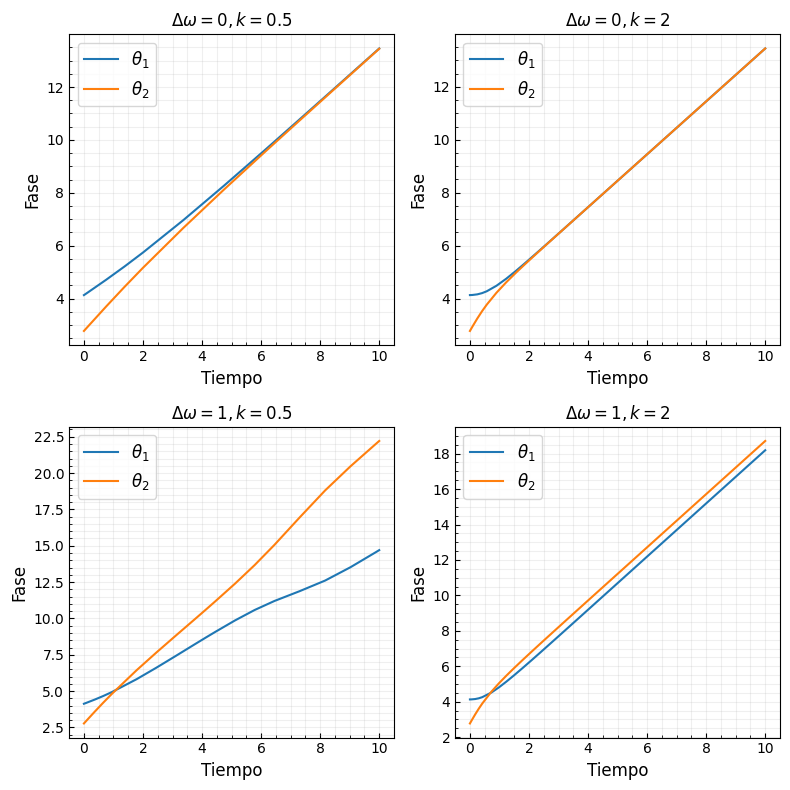

In [66]:
# Definimos las condiciones iniciales aleatorias entre 0 y 2pi
y0 = np.random.uniform(0, 2*np.pi, 2)

# Definimos las frecuencias naturales de los osciladores, vamos a dar primero una diferencia de 0, luego de 3 y luego de 5
omegas = [[1, 1], [1, 2]]

# Vamos a dar una cantidad de acoplamientos distitnos para ver como se comportan estos tres casos
ks = [0.5, 2]

# Definimos el tiempo de integración
t_span = (0, 10)

# Definimos el tiempo de integración
t = np.linspace(0, 10, 1000)

fig, ax = plt.subplots(2, 2, figsize=(8, 8))
# fig2, ax2 = plt.subplots(2, 2, figsize=(8, 8))
grid = itertools.product(omegas, ks)

for i, (omega, k) in enumerate(grid):
    sol = solve_ivp(dososciladoresfase, t_span, y0, method='LSODA', args=(omega, k), dense_output=True)
    ax[i//2, i%2].plot(sol.t, sol.y[0], label=r'$\theta_1$')
    ax[i//2, i%2].plot(sol.t, sol.y[1], label=r'$\theta_2$')
    ax[i//2, i%2].set_title(f'$\Delta \omega = {omega[1]-omega[0]}, k = {k}$')
    ax[i//2, i%2].legend(fontsize = 12)
    ax[i//2, i%2].xaxis.set_minor_locator(AutoMinorLocator())
    ax[i//2, i%2].yaxis.set_minor_locator(AutoMinorLocator())
    ax[i//2, i%2].tick_params(which='both', direction='in')
    ax[i//2, i%2].grid(which='both', alpha=0.2)
    ax[i//2, i%2].set_xlabel('Tiempo', fontsize = 12)
    ax[i//2, i%2].set_ylabel('Fase', fontsize = 12)

    # w = frecuencias(t, sol.sol(t), omega, k)
    # for j in range(2):
    #     ax2[i//2, i%2].plot(t, w[j], label=f'$\omega_{j+1}$')
    # ax2[i//2, i%2].set_title(f'$\Delta \omega = {omega[1]-omega[0]}, k = {k}$')
    # ax2[i//2, i%2].legend(fontsize = 12)
    # ax2[i//2, i%2].xaxis.set_minor_locator(AutoMinorLocator())
    # ax2[i//2, i%2].yaxis.set_minor_locator(AutoMinorLocator())
    # ax2[i//2, i%2].tick_params(which='both', direction='in')
    # ax2[i//2, i%2].grid(which='both', alpha=0.2)
    # ax2[i//2, i%2].set_xlabel('Tiempo', fontsize = 12)
    # ax2[i//2, i%2].set_ylabel('Frecuencia', fontsize = 12)
plt.tight_layout()
# plt.savefig('fases.pdf')
plt.show()

Observamos que para $\Delta \omega = 0$ los ociladores tienden a un estado de sincronización sin importar el valor de $k$ mientras que si $\Delta \omega > k$ los osciladores no se sincronizan pero para $\Delta \omega < k$ los osciladores tienden a tener una fase constante entre ellos en lo que denominamos phase locking.

In [72]:
# Definimos el sistema de ecuaciones diferenciales de fases para 5 osciladores acoplados
def osciladoresfase(t, y, omegas, k):
    th1, th2, th3, th4, th5 = y
    omega1, omega2, omega3, omega4, omega5 = omegas
    N = len(y)
    dth1dt = omega1 + k/N * (np.sin(th2 - th1) + np.sin(th3 - th1) + np.sin(th4 - th1) + np.sin(th5 - th1))
    dth2dt = omega2 + k/N * (np.sin(th1 - th2) + np.sin(th3 - th2) + np.sin(th4 - th2) + np.sin(th5 - th2))
    dth3dt = omega3 + k/N * (np.sin(th1 - th3) + np.sin(th2 - th3) + np.sin(th4 - th3) + np.sin(th5 - th3))
    dth4dt = omega4 + k/N * (np.sin(th1 - th4) + np.sin(th2 - th4) + np.sin(th3 - th4) + np.sin(th5 - th4))
    dth5dt = omega5 + k/N * (np.sin(th1 - th5) + np.sin(th2 - th5) + np.sin(th3 - th5) + np.sin(th4 - th5))

    return [dth1dt, dth2dt, dth3dt, dth4dt, dth5dt]

Quiero ver que para un $k$ suficientemente grande los osciladores se sincronizarán.

Comenzemos con 5 osciladores con frecuencias parecidas

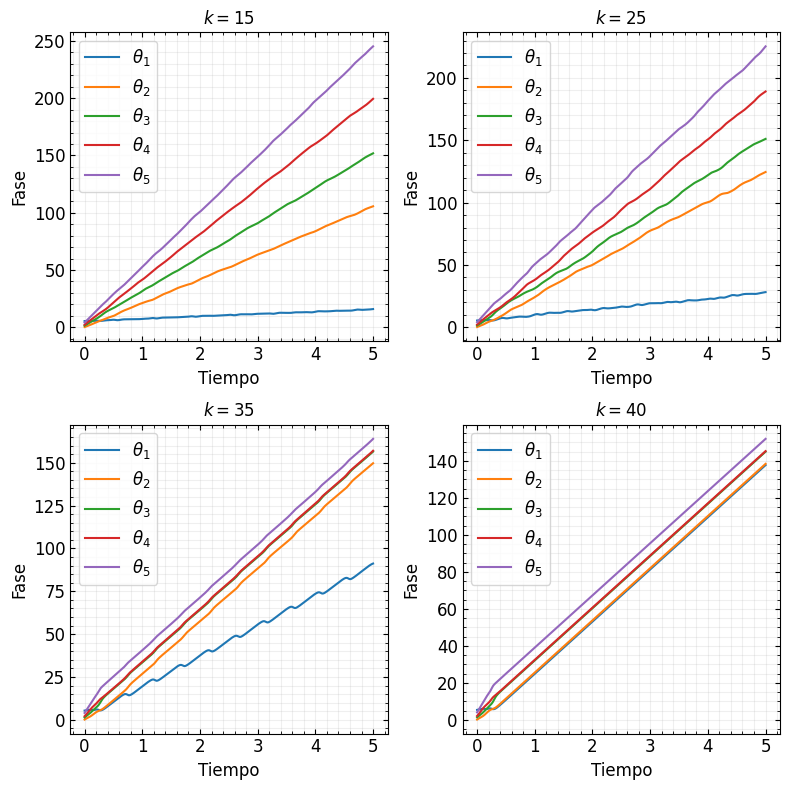

In [113]:
# Definimos el tiempo de integración
t_span = (0, 5)

# Definimos el tiempo
t = np.linspace(t_span[0], t_span[1], 1000)

# Definimos las condiciones iniciales
y0 = np.random.uniform(0, 2*np.pi, 5)

# Definimos las frecuencias naturales de los osciladores
omegas = [1,20,30,40,50]

# Definimos la constante de acoplamiento
ks = [15, 25, 35, 40]

fig, ax = plt.subplots(2, 2, figsize=(8, 8))
ax = ax.ravel()
for i, k in enumerate(ks):
    sol = solve_ivp(osciladoresfase, t_span, y0, method='LSODA', args=(omegas, k), dense_output=True)
    y = sol.sol(t)
    for j in range(5):
        ax[i].plot(t, y[j], label=r'$\theta_{}$'.format(j+1))
    ax[i].set_title(f'$k = {k}$')
    ax[i].legend(fontsize = 12)
    ax[i].xaxis.set_minor_locator(AutoMinorLocator())
    ax[i].yaxis.set_minor_locator(AutoMinorLocator())
    ax[i].tick_params(axis='both', which='both', direction='in', top=True, right=True, labelsize=12)
    ax[i].grid(which='both', alpha=0.2)
    ax[i].set_xlabel('Tiempo', fontsize = 12)
    ax[i].set_ylabel('Fase', fontsize = 12)

plt.tight_layout()
plt.savefig('fases5v2.pdf')
plt.show()

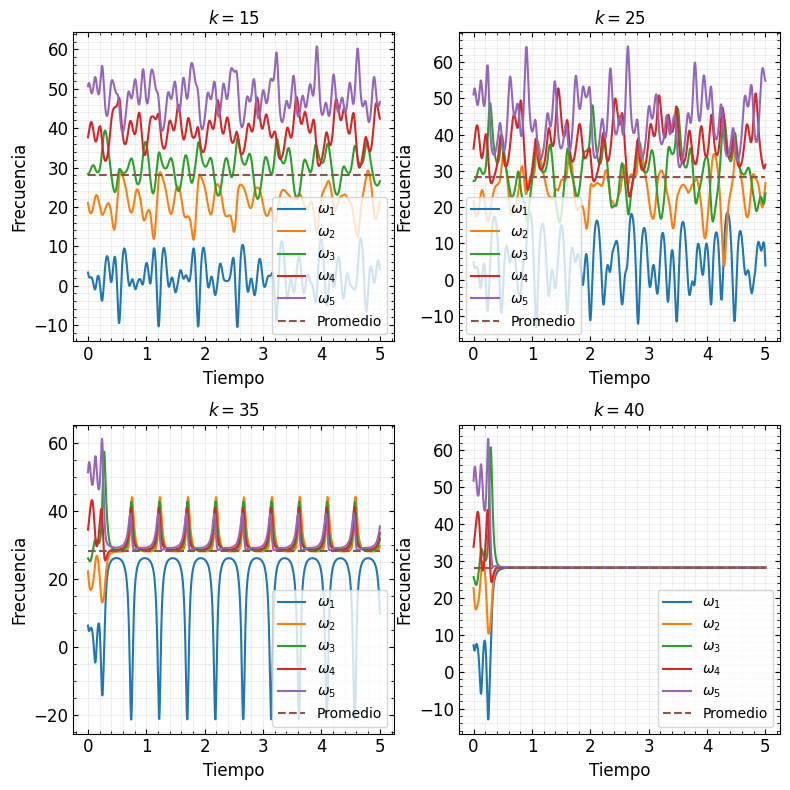

In [114]:
fig, ax = plt.subplots(2,2 , figsize=(8, 8))
ax = ax.ravel()
for i,k in enumerate(ks):
    sol = solve_ivp(osciladoresfase, t_span, y0, method='LSODA', args=(omegas, k), dense_output=True)
    y = sol.sol(t)
    # Obtenemos las frecuencias de los osciladores
    w = frecuencias(t,y,omegas,k)
    # Calculamos el promedio de las frecuencias
    w_prom = np.mean(w, axis=0)
    for j in range(len(w)):
        ax[i].plot(t, w[j], label=r'$\omega_{}$'.format(j+1))
    ax[i].plot(t, w_prom, label='Promedio', linestyle='--')
    ax[i].set_title(f'$k = {k}$')
    ax[i].legend(fontsize = 10)
    ax[i].xaxis.set_minor_locator(AutoMinorLocator())
    ax[i].yaxis.set_minor_locator(AutoMinorLocator())
    ax[i].tick_params(axis='both', which='both', direction='in', top=True, right=True, labelsize=12)
    ax[i].grid(which='both', alpha=0.2)
    ax[i].set_xlabel('Tiempo', fontsize = 12)
    ax[i].set_ylabel('Frecuencia', fontsize = 12)
plt.tight_layout()
plt.savefig('frecuencias5v2.pdf')
plt.show()

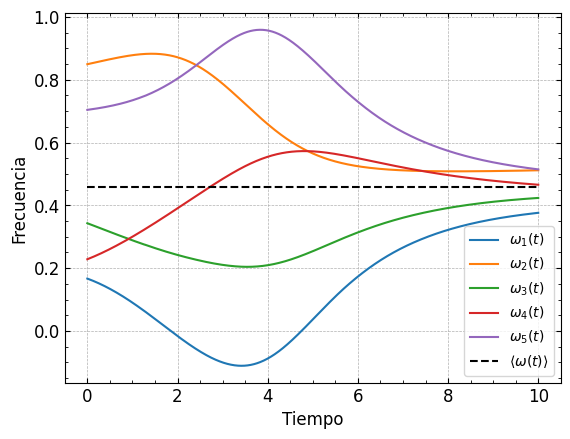

In [14]:
# Obtenemos las frecuencias de los osciladores
w = frecuencias(t,y,omegas,k)

# Calculamos el promedio de las frecuencias
w_prom = np.mean(w, axis=0)

# Graficamos las frecuencias de los osciladores
fig, ax = plt.subplots()
ax.plot(t, w[0], label=r'$\omega_1(t)$')
ax.plot(t, w[1], label=r'$\omega_2(t)$')
ax.plot(t, w[2], label=r'$\omega_3(t)$')
ax.plot(t, w[3], label=r'$\omega_4(t)$')
ax.plot(t, w[4], label=r'$\omega_5(t)$')
ax.plot(t, w_prom, label=r'$\langle \omega(t) \rangle$', color='black', linestyle='--')
ax.set_xlabel('Tiempo', fontsize=12)
ax.set_ylabel('Frecuencia', fontsize=12)
ax.xaxis.set_major_locator(plt.AutoLocator())
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_major_locator(plt.AutoLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='both', which='both', direction='in', top=True, right=True, labelsize=12)
ax.grid(linestyle='--', linewidth=0.5)
ax.legend()
plt.show()